# EDA on Dehli Dataset

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [20]:
# ----------------------------
# 1) Load data
# ----------------------------
PATH = "delhi_ncr_aqi_dataset.csv"
df = pd.read_csv(PATH)

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())

# ----------------------------
# 2) Parse datetime + basic cleaning
# ----------------------------
# Try to parse a 'datetime' column if present, else fall back to 'date' + 'hour'
if "datetime" in df.columns:
    df["datetime"] = pd.to_datetime(df["datetime"], errors="coerce")
elif "date" in df.columns and "hour" in df.columns:
    df["datetime"] = pd.to_datetime(df["date"], errors="coerce") + pd.to_timedelta(df["hour"], unit="h")
else:
    df["datetime"] = pd.NaT

df['day_of_week'] = df['datetime'].dt.dayofweek

# Ensure numeric columns are numeric (coerce errors to NaN)
num_cols = ["pm25","pm10","no2","so2","co","o3","temperature","humidity","wind_speed","visibility","aqi",
            "latitude","longitude","year","month","day","hour","is_weekend"]
for c in num_cols:
    if c in df.columns:
        df[c] = pd.to_numeric(df[c], errors="coerce")

# Quick duplicates check
dupes = df.duplicated().sum()
print("\nDuplicate rows:", dupes)

# Sort by time if available
if df["datetime"].notna().any():
    df = df.sort_values("datetime")

Shape: (201664, 25)

Columns: ['datetime', 'date', 'year', 'month', 'day', 'hour', 'day_of_week', 'is_weekend', 'season', 'city', 'station', 'latitude', 'longitude', 'pm25', 'pm10', 'no2', 'so2', 'co', 'o3', 'temperature', 'humidity', 'wind_speed', 'visibility', 'aqi', 'aqi_category']

Duplicate rows: 0


In [32]:
def summarize_dataframe(df: pd.DataFrame, top_n: int = 5) -> pd.DataFrame:
    summary = []

    for col in df.columns:
        col_data = df[col]
        col_summary = {
            "column": col,
            "dtype": col_data.dtype,
            "num_rows": len(col_data),
            "num_missing": col_data.isna().sum(),
            "pct_missing": round(col_data.isna().mean() * 100, 2),
            "num_unique": col_data.nunique(dropna=True)
        }

        # Numeric columns
        if pd.api.types.is_numeric_dtype(col_data):
            col_summary.update({
                "mean": col_data.mean(),
                "std": col_data.std(),
                "min": col_data.min(),
                "p25": col_data.quantile(0.25),
                "median": col_data.median(),
                "p75": col_data.quantile(0.75),
                "max": col_data.max()
            })

        # Datetime columns
        elif pd.api.types.is_datetime64_any_dtype(col_data):
            col_summary.update({
                "min_date": col_data.min(),
                "max_date": col_data.max()
            })

        # Categorical / object columns
        else:
            top_values = col_data.value_counts(dropna=True).head(top_n)
            col_summary.update({
                "top_values": dict(top_values)
            })

        summary.append(col_summary)

    return pd.DataFrame(summary)

df_summary = summarize_dataframe(df)
df_summary

,column,dtype,num_rows,num_missing,pct_missing,num_unique,min_date,max_date,top_values,mean,std,min,p25,median,p75,max
0,datetime,datetime64[ns],201664,0,0.00,8768,2020-01-01 06:00:00,2025-12-31 23:00:00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,date,object,201664,0,0.00,2192,NaT,NaT,"{'2020-01-01': 92, '2024-01-04': 92, '2023-12-...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,year,int64,201664,0,0.00,6,NaT,NaT,NaN,2022.499544,1.708185,2020.0000,2021.0000,2022.5000,2024.0000,2025.0000
3,month,int64,201664,0,0.00,12,NaT,NaT,NaN,6.521898,3.448995,1.0000,4.0000,7.0000,10.0000,12.0000
4,day,int64,201664,0,0.00,31,NaT,NaT,NaN,15.732664,8.801392,1.0000,8.0000,16.0000,23.0000,31.0000
5,hour,int64,201664,0,0.00,4,NaT,NaT,NaN,14.750000,6.378691,6.0000,10.5000,15.0000,19.2500,23.0000
6,day_of_week,int32,201664,0,0.00,7,NaT,NaT,NaN,2.999544,1.999663,0.0000,1.0000,3.0000,5.0000,6.0000
7,is_weekend,int64,201664,0,0.00,2,NaT,NaT,NaN,0.285584,0.451693,0.0000,0.0000,0.0000,1.0000,1.0000
8,season,object,201664,0,0.00,4,NaT,NaT,"{'monsoon': 67344, 'winter': 66424, 'summer': ...",NaN,NaN,NaN,NaN,NaN,NaN,NaN
9,city,object,201664,0,0.00,5,NaT,NaT,"{'Delhi': 122752, 'Noida': 26304, 'Faridabad':...",NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [38]:
# Show unique (city, station) pairs and count of stations per city
unique_stations = df[['city', 'station']].drop_duplicates()
print(unique_stations)

station_counts = unique_stations.groupby('city')['station'].nunique()
print("\nStation count per city:")
print(station_counts)

         city               station
0       Delhi    Anand Vihar, Delhi
12      Delhi         Bawana, Delhi
44      Delhi   Dwarka Sec 8, Delhi
80  Faridabad    Faridabad New Town
76  Faridabad     Faridabad Sec 16A
88  Ghaziabad        Ghaziabad Loni
84  Ghaziabad  Ghaziabad Vasundhara
64      Noida         Greater Noida
72   Gurugram       Gurugram Sec 51
68   Gurugram  Gurugram Vikas Sadan
16      Delhi            ITO, Delhi
4       Delhi   Jahangirpuri, Delhi
52      Delhi    Mandir Marg, Delhi
48      Delhi    NSIT Dwarka, Delhi
60      Noida         Noida Sec 125
56      Noida          Noida Sec 62
24      Delhi  Okhla Phase 2, Delhi
20      Delhi   Punjabi Bagh, Delhi
36      Delhi       RK Puram, Delhi
32      Delhi         Rohini, Delhi
28      Delhi       Shadipur, Delhi
40      Delhi      Siri Fort, Delhi
8       Delhi       Wazirpur, Delhi

Station count per city:
city
Delhi        14
Faridabad     2
Ghaziabad     2
Gurugram      2
Noida         3
Name: station, dtype: int6


--- Head ---
              datetime        date  year  month  day  hour  day_of_week  \
0  2020-01-01 06:00:00  2020-01-01  2020      1    1     6            2   
52 2020-01-01 06:00:00  2020-01-01  2020      1    1     6            2   
48 2020-01-01 06:00:00  2020-01-01  2020      1    1     6            2   
60 2020-01-01 06:00:00  2020-01-01  2020      1    1     6            2   
44 2020-01-01 06:00:00  2020-01-01  2020      1    1     6            2   

    is_weekend  season   city  ...    no2   so2    co    o3  temperature  \
0            0  winter  Delhi  ...  119.6  47.7  5.19  12.3          9.4   
52           0  winter  Delhi  ...   94.7  16.4  4.38  24.5          8.3   
48           0  winter  Delhi  ...  111.2  22.6  5.13  15.2          9.9   
60           0  winter  Noida  ...   86.0  18.6  3.26  20.9          9.4   
44           0  winter  Delhi  ...   89.8  15.9  4.23  21.5          7.4   

    humidity  wind_speed  visibility  aqi  aqi_category  
0        100        

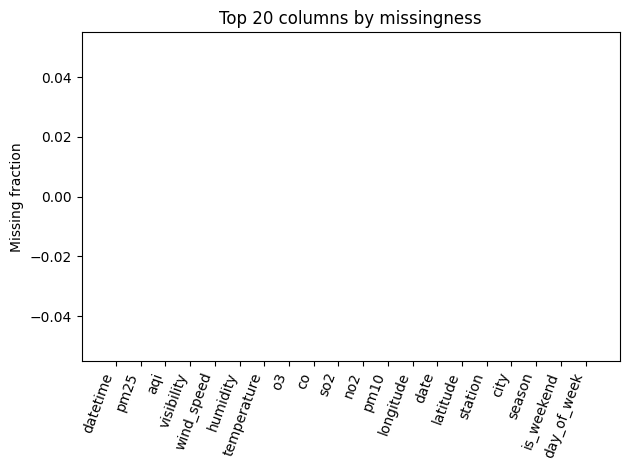

In [21]:
# ----------------------------
# 3) Data quality overview
# ----------------------------
print("\n--- Head ---")
print(df.head())

print("\n--- Info ---")
print(df.info())

print("\n--- Missing values (top 30) ---")
missing = df.isna().mean().sort_values(ascending=False)
print((missing.head(30) * 100).round(2).astype(str) + "%")

# Missing heatmap-like bar plot (top 20)
top_missing = missing.head(20)
plt.figure()
plt.bar(top_missing.index.astype(str), top_missing.values)
plt.xticks(rotation=70, ha="right")
plt.ylabel("Missing fraction")
plt.title("Top 20 columns by missingness")
plt.tight_layout()
plt.show()

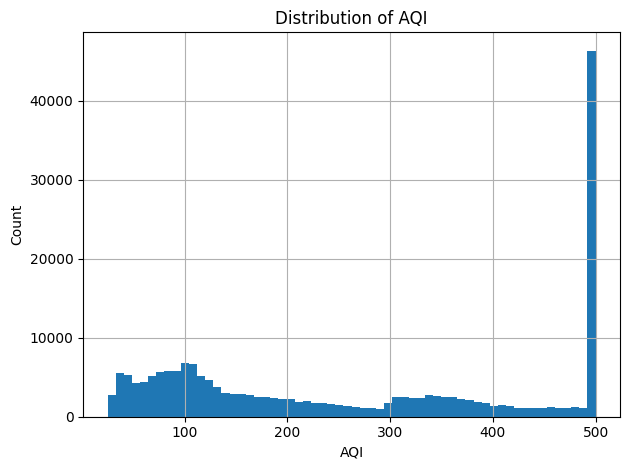

In [22]:
# ----------------------------
# 4) Basic target exploration: AQI distribution + category counts
# ----------------------------
if "aqi" in df.columns:
    plt.figure()
    df["aqi"].dropna().hist(bins=60)
    plt.xlabel("AQI")
    plt.ylabel("Count")
    plt.title("Distribution of AQI")
    plt.tight_layout()
    plt.show()

if "aqi_cate" in df.columns:
    cate_counts = df["aqi_cate"].astype(str).value_counts(dropna=False)
    print("\n--- AQI Category counts ---")
    print(cate_counts)

    plt.figure()
    plt.bar(cate_counts.index.astype(str), cate_counts.values)
    plt.xticks(rotation=45, ha="right")
    plt.ylabel("Count")
    plt.title("AQI Category Frequency")
    plt.tight_layout()
    plt.show()



In [23]:
# ----------------------------
# 5) Time coverage + station coverage
# ----------------------------
if df["datetime"].notna().any():
    print("\n--- Time range ---")
    print("Min datetime:", df["datetime"].min())
    print("Max datetime:", df["datetime"].max())

if "city" in df.columns:
    print("\n--- City counts ---")
    print(df["city"].astype(str).value_counts().head(10))

if "station" in df.columns:
    print("\n--- Station counts (top 15) ---")
    print(df["station"].astype(str).value_counts().head(15))




--- Time range ---
Min datetime: 2020-01-01 06:00:00
Max datetime: 2025-12-31 23:00:00

--- City counts ---
city
Delhi        122752
Noida         26304
Gurugram      17536
Faridabad     17536
Ghaziabad     17536
Name: count, dtype: int64

--- Station counts (top 15) ---
station
Anand Vihar, Delhi      8768
Okhla Phase 2, Delhi    8768
Bawana, Delhi           8768
ITO, Delhi              8768
Ghaziabad Vasundhara    8768
Ghaziabad Loni          8768
Wazirpur, Delhi         8768
Noida Sec 62            8768
Faridabad New Town      8768
Punjabi Bagh, Delhi     8768
Faridabad Sec 16A       8768
Shadipur, Delhi         8768
Mandir Marg, Delhi      8768
Gurugram Sec 51         8768
Rohini, Delhi           8768
Name: count, dtype: int64


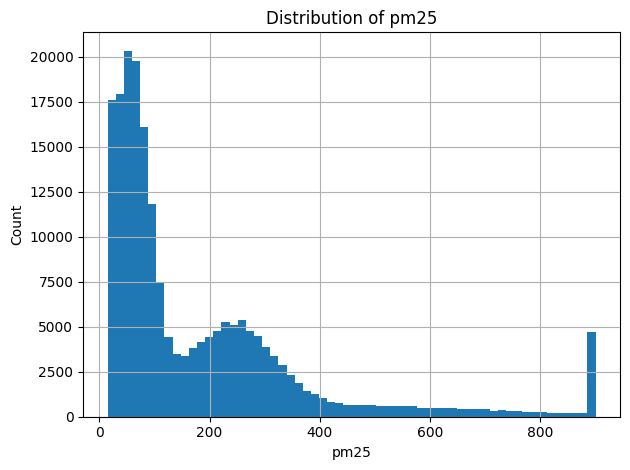

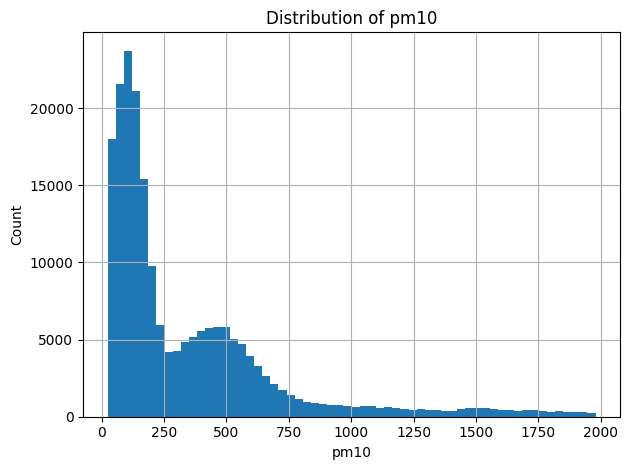

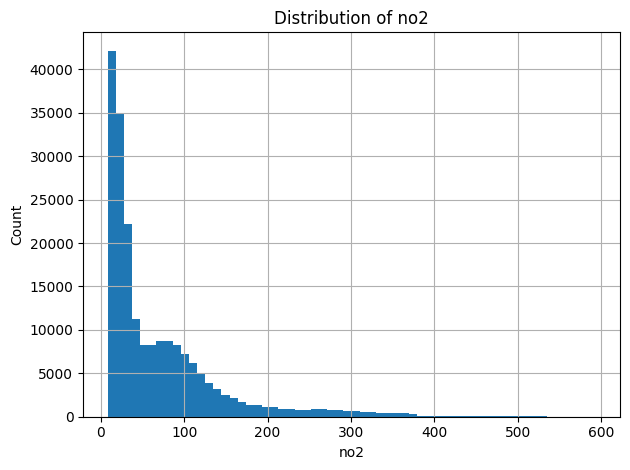

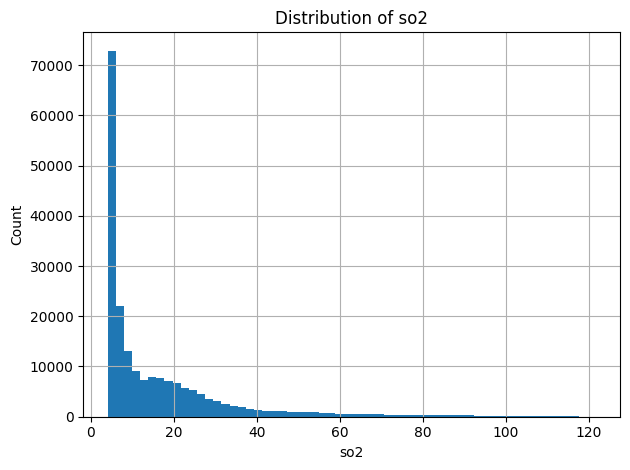

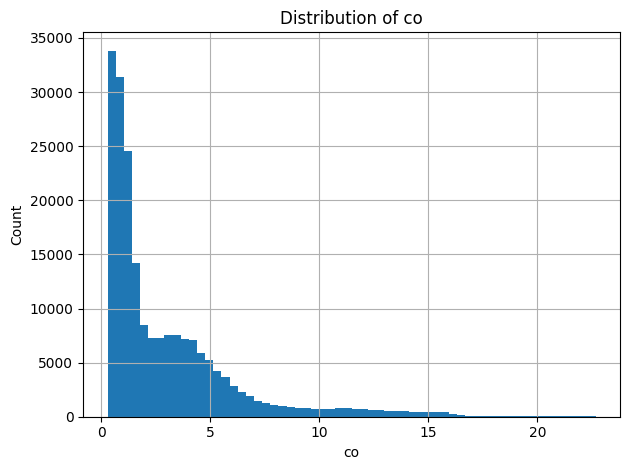

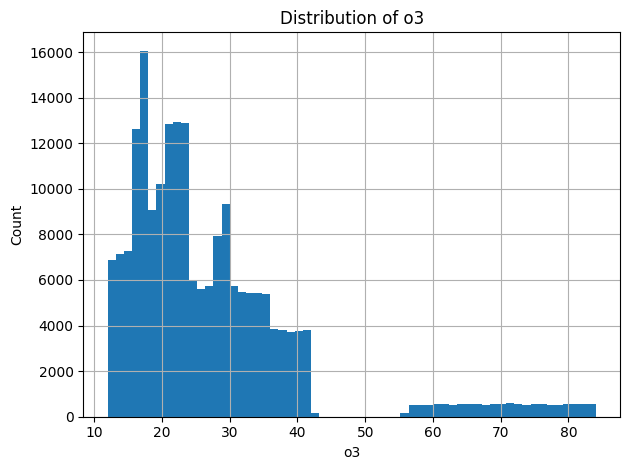

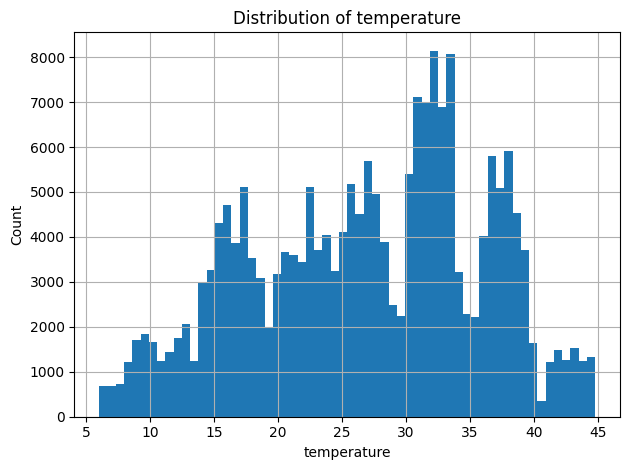

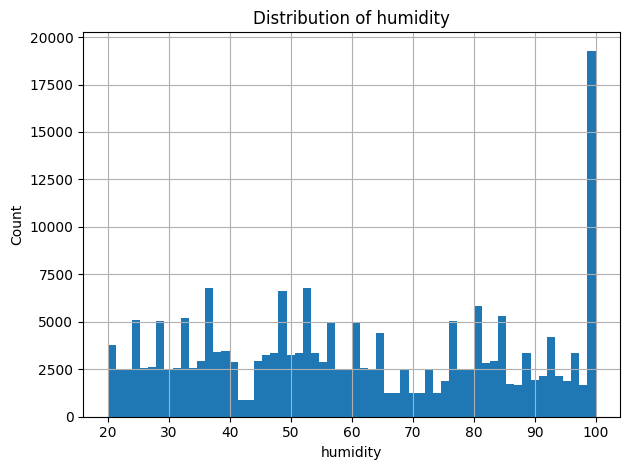

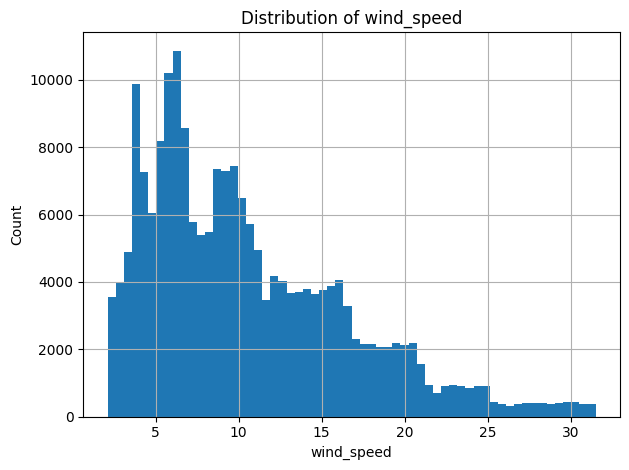

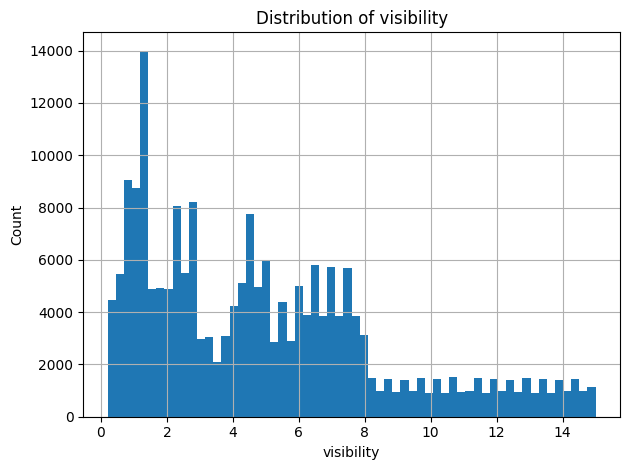

In [24]:
# ----------------------------
# 6) Univariate plots for pollutants + weather
# ----------------------------
pollutants = [c for c in ["pm25","pm10","no2","so2","co","o3"] if c in df.columns]
weather = [c for c in ["temperature","humidity","wind_speed","visibility"] if c in df.columns]

for col in pollutants + weather:
    plt.figure()
    df[col].dropna().hist(bins=60)
    plt.xlabel(col)
    plt.ylabel("Count")
    plt.title(f"Distribution of {col}")
    plt.tight_layout()
    plt.show()




--- Correlation with AQI (pairwise complete) ---
aqi            1.000000
pm25           0.800847
pm10           0.797940
co             0.777170
no2            0.773582
so2            0.755249
humidity      -0.223593
o3            -0.284010
wind_speed    -0.537265
temperature   -0.734334
visibility    -0.857166
Name: aqi, dtype: float64


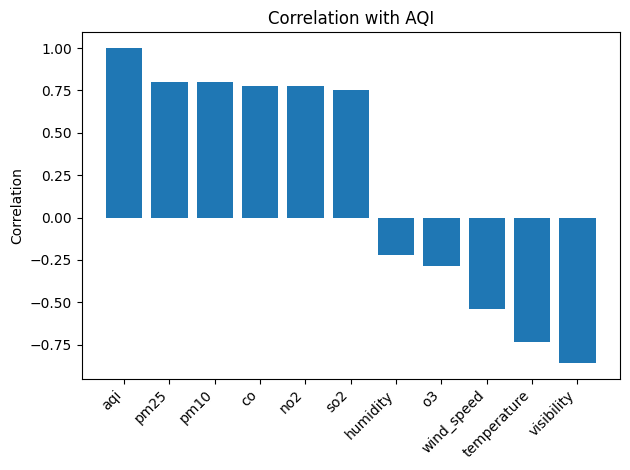

In [25]:
# ----------------------------
# 7) Correlation with AQI (numeric only)
# ----------------------------
if "aqi" in df.columns:
    # pick numeric columns that exist
    corr_cols = [c for c in (pollutants + weather + ["aqi"]) if c in df.columns]
    corr_df = df[corr_cols].dropna()
    if len(corr_df) > 0:
        corr = corr_df.corr(numeric_only=True)["aqi"].sort_values(ascending=False)
        print("\n--- Correlation with AQI (pairwise complete) ---")
        print(corr)

        # bar plot correlations
        plt.figure()
        plt.bar(corr.index.astype(str), corr.values)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Correlation")
        plt.title("Correlation with AQI")
        plt.tight_layout()
        plt.show()



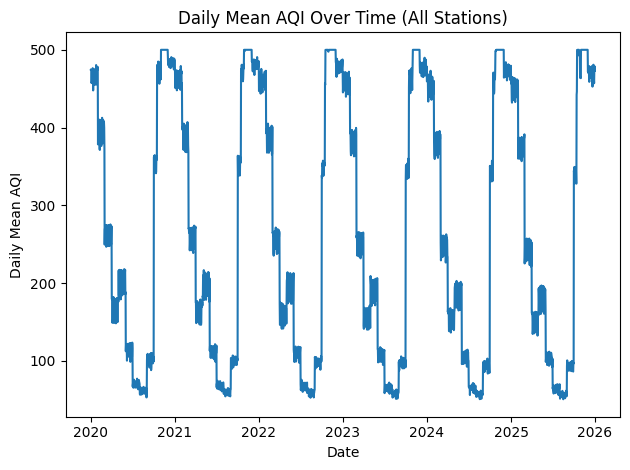

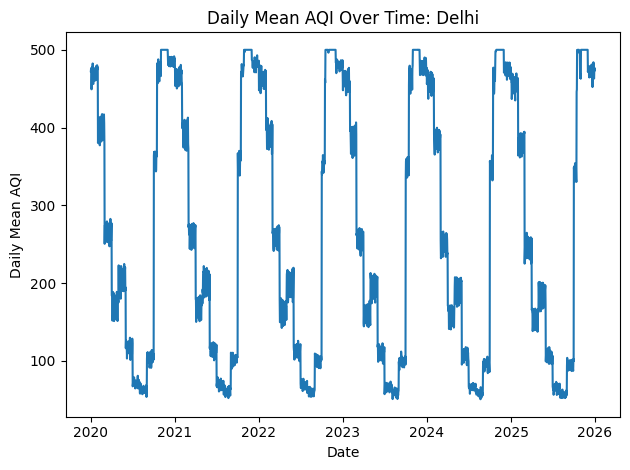

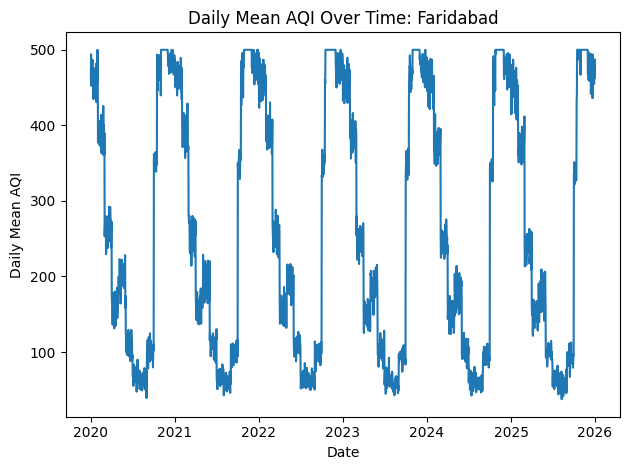

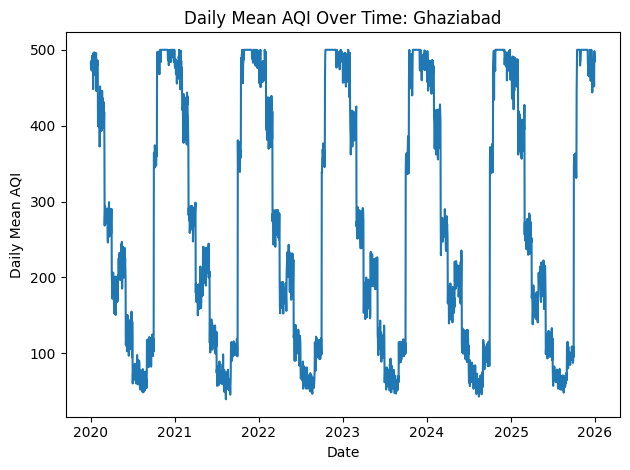

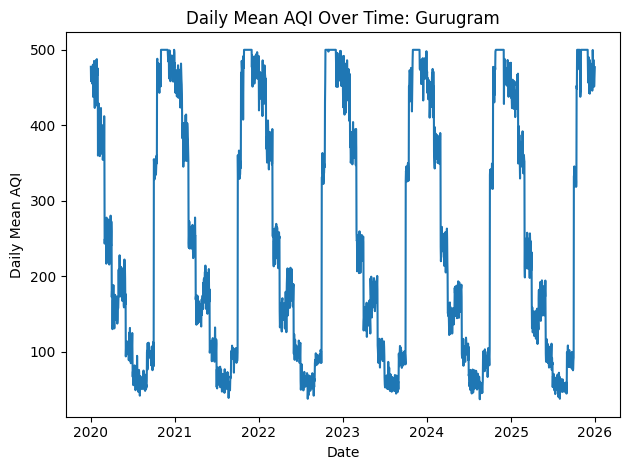

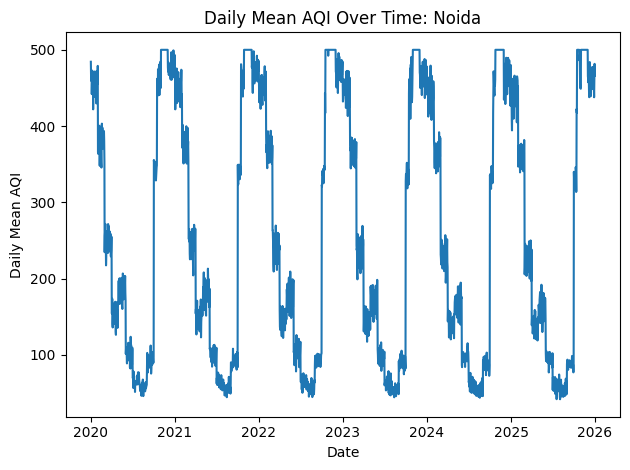

In [26]:
# ----------------------------
# 8) Time-series plots: AQI over time (overall + by city)
# ----------------------------
if df["datetime"].notna().any() and "aqi" in df.columns:
    # Overall daily mean AQI to smooth hourly noise
    daily = df.set_index("datetime")["aqi"].resample("D").mean()

    plt.figure()
    plt.plot(daily.index, daily.values)
    plt.xlabel("Date")
    plt.ylabel("Daily Mean AQI")
    plt.title("Daily Mean AQI Over Time (All Stations)")
    plt.tight_layout()
    plt.show()

    # By city (daily mean)
    if "city" in df.columns:
        # Use a small set of top cities (should be 5)
        cities = df["city"].dropna().unique().tolist()
        for city in sorted(cities)[:5]:
            city_daily = (
                df[df["city"] == city]
                .set_index("datetime")["aqi"]
                .resample("D").mean()
            )
            plt.figure()
            plt.plot(city_daily.index, city_daily.values)
            plt.xlabel("Date")
            plt.ylabel("Daily Mean AQI")
            plt.title(f"Daily Mean AQI Over Time: {city}")
            plt.tight_layout()
            plt.show()



In [29]:
by_hour

hour
6     271.307521
12    243.356514
18    281.620002
23    267.036556
Name: aqi, dtype: float64

<Figure size 640x480 with 0 Axes>

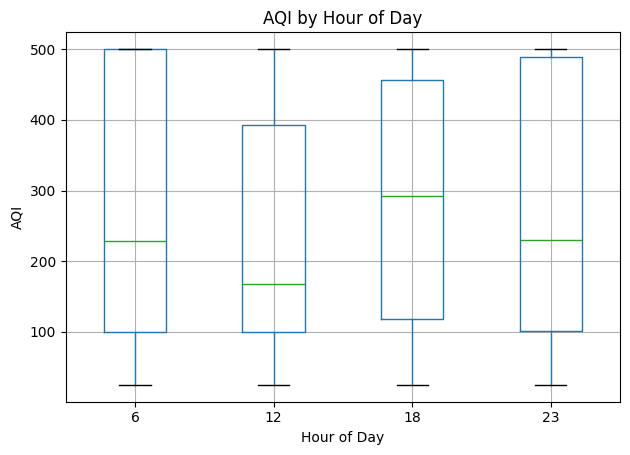

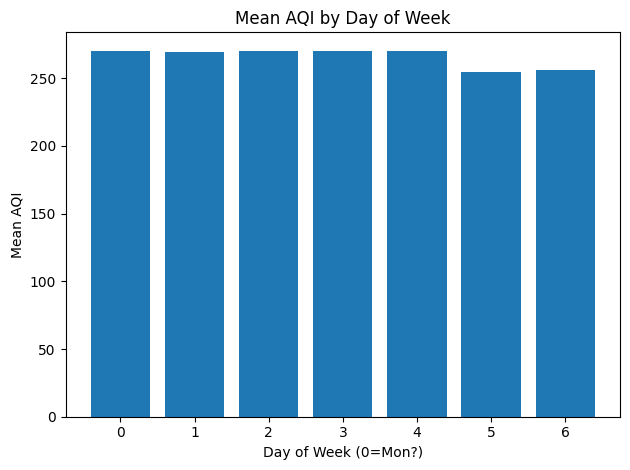

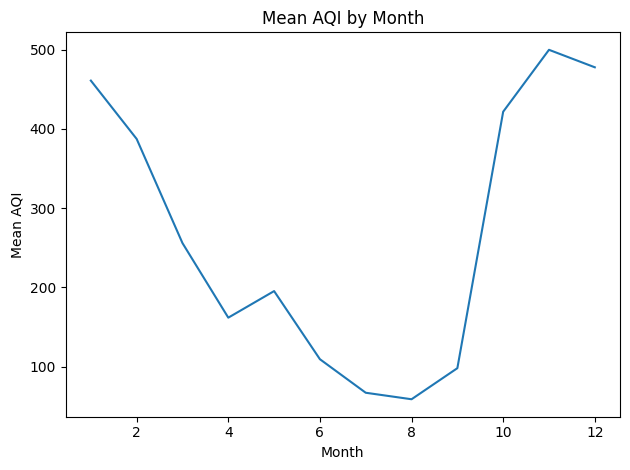

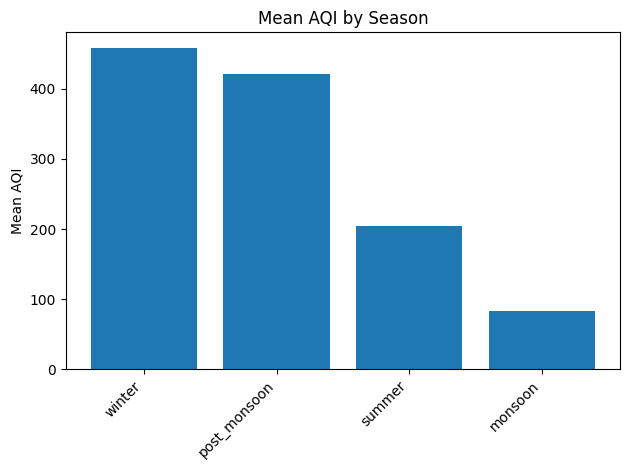

In [30]:
# ----------------------------
# 9) Seasonality: AQI by hour, day_of_week, month, season
# ----------------------------
if "aqi" in df.columns:
    if "hour" in df.columns:
        plt.figure()
        df.boxplot(column="aqi", by="hour")
        plt.xlabel("Hour of Day")
        plt.ylabel("AQI")
        plt.title("AQI by Hour of Day")
        plt.suptitle("")  # Remove automatic 'Boxplot grouped by hour' suptitle
        plt.tight_layout()
        plt.show()

    if "day_of_week" in df.columns:
        by_dow = df.groupby("day_of_week")["aqi"].mean()
        plt.figure()
        plt.bar(by_dow.index.astype(int), by_dow.values)
        plt.xlabel("Day of Week (0=Mon?)")
        plt.ylabel("Mean AQI")
        plt.title("Mean AQI by Day of Week")
        plt.tight_layout()
        plt.show()

    if "month" in df.columns:
        by_month = df.groupby("month")["aqi"].mean()
        plt.figure()
        plt.plot(by_month.index, by_month.values)
        plt.xlabel("Month")
        plt.ylabel("Mean AQI")
        plt.title("Mean AQI by Month")
        plt.tight_layout()
        plt.show()

    if "season" in df.columns:
        by_season = df.groupby("season")["aqi"].mean().sort_values(ascending=False)
        plt.figure()
        plt.bar(by_season.index.astype(str), by_season.values)
        plt.xticks(rotation=45, ha="right")
        plt.ylabel("Mean AQI")
        plt.title("Mean AQI by Season")
        plt.tight_layout()
        plt.show()




--- Top 20 stations by mean AQI ---
station
Anand Vihar, Delhi      295.166857
Jahangirpuri, Delhi     289.718864
Wazirpur, Delhi         286.587363
Bawana, Delhi           283.694685
Ghaziabad Loni          279.569229
ITO, Delhi              276.974110
Okhla Phase 2, Delhi    274.130703
Ghaziabad Vasundhara    270.587021
Punjabi Bagh, Delhi     270.277258
Shadipur, Delhi         266.125114
Faridabad Sec 16A       266.105497
Noida Sec 62            263.219434
Rohini, Delhi           263.038663
Gurugram Vikas Sadan    260.431797
Faridabad New Town      260.427464
Gurugram Sec 51         256.009580
Noida Sec 125           255.898609
RK Puram, Delhi         255.609261
Siri Fort, Delhi        251.157619
Greater Noida           248.491104
Name: aqi, dtype: float64


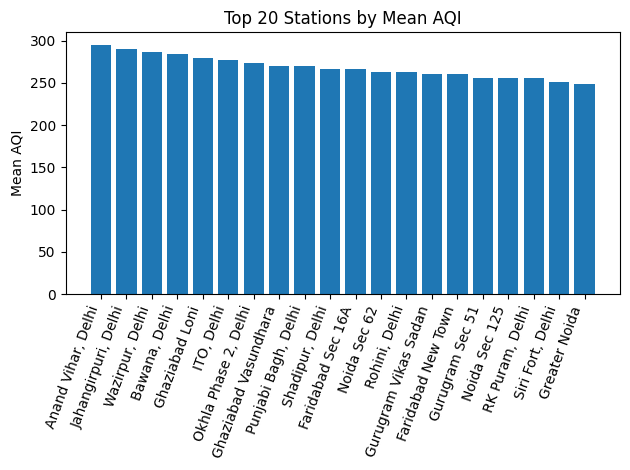

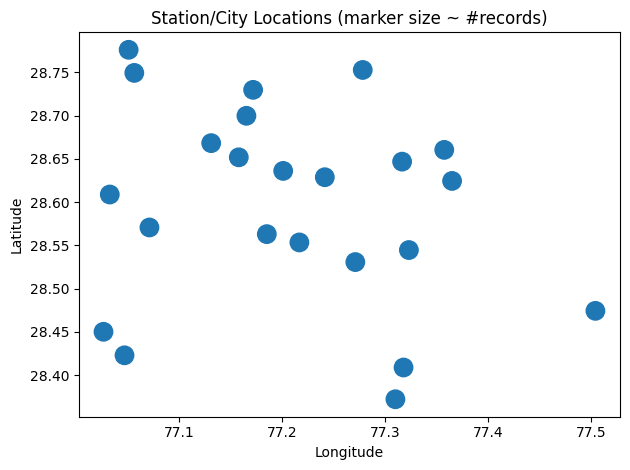

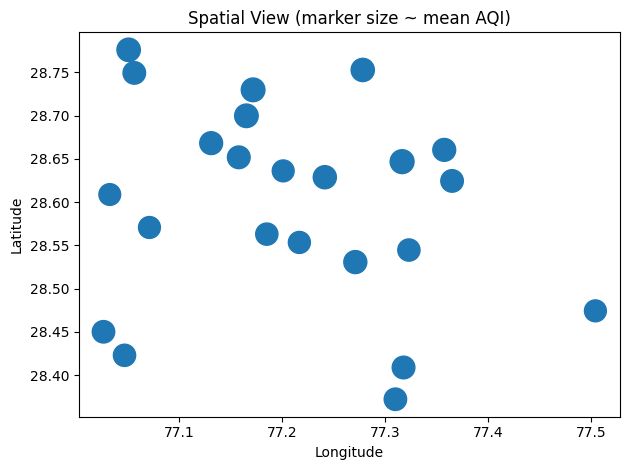


Forecast target created: aqi_tplus1
Non-null aqi_tplus1 rows: 201641 out of 201664


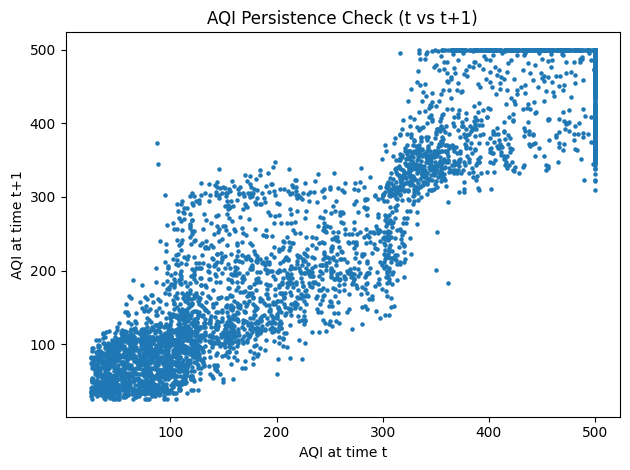


EDA done.


In [28]:
# ----------------------------
# 10) Spatial sanity checks: AQI by station + coordinates
# ----------------------------
if "aqi" in df.columns and "station" in df.columns:
    station_mean = df.groupby("station")["aqi"].mean().sort_values(ascending=False).head(20)
    print("\n--- Top 20 stations by mean AQI ---")
    print(station_mean)

    plt.figure()
    plt.bar(station_mean.index.astype(str), station_mean.values)
    plt.xticks(rotation=70, ha="right")
    plt.ylabel("Mean AQI")
    plt.title("Top 20 Stations by Mean AQI")
    plt.tight_layout()
    plt.show()

# Optional: scatter of station average AQI on lat/long (simple spatial view)
if all(c in df.columns for c in ["latitude", "longitude", "aqi"]) and df[["latitude","longitude"]].notna().all(axis=1).any():
    station_geo = df.dropna(subset=["latitude","longitude","aqi"])
    # Aggregate to station if station exists, else use city
    group_key = "station" if "station" in df.columns else ("city" if "city" in df.columns else None)
    if group_key is not None:
        agg = station_geo.groupby(group_key).agg(
            latitude=("latitude","mean"),
            longitude=("longitude","mean"),
            mean_aqi=("aqi","mean"),
            n=("aqi","size")
        ).reset_index()

        plt.figure()
        plt.scatter(agg["longitude"], agg["latitude"], s=np.clip(agg["n"] / 50, 10, 300))
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.title("Station/City Locations (marker size ~ #records)")
        plt.tight_layout()
        plt.show()

        plt.figure()
        plt.scatter(agg["longitude"], agg["latitude"], s=np.clip(agg["mean_aqi"], 10, 300))
        plt.xlabel("Longitude")
        plt.ylabel("Latitude")
        plt.title("Spatial View (marker size ~ mean AQI)")
        plt.tight_layout()
        plt.show()

# ----------------------------
# 11) Leakage check idea for forecasting setup
# ----------------------------
# If you plan to forecast AQI(t+1), you must build target shifted forward within each station.
# This block creates it (no model training yet), and shows how many rows survive after shifting.
if df["datetime"].notna().any() and "aqi" in df.columns and "station" in df.columns:
    df = df.sort_values(["station", "datetime"])
    df["aqi_tplus1"] = df.groupby("station")["aqi"].shift(-1)

    print("\nForecast target created: aqi_tplus1")
    print("Non-null aqi_tplus1 rows:", df["aqi_tplus1"].notna().sum(), "out of", len(df))

    # Quick scatter: current AQI vs next-hour AQI (should show strong relationship)
    sample = df.dropna(subset=["aqi", "aqi_tplus1"]).sample(min(5000, df.dropna(subset=["aqi","aqi_tplus1"]).shape[0]), random_state=42)
    plt.figure()
    plt.scatter(sample["aqi"], sample["aqi_tplus1"], s=5)
    plt.xlabel("AQI at time t")
    plt.ylabel("AQI at time t+1")
    plt.title("AQI Persistence Check (t vs t+1)")
    plt.tight_layout()
    plt.show()

print("\nEDA done.")
